<a href="https://colab.research.google.com/github/almasmadii/Programming-Languages-Data-Visualization-/blob/main/Programming_Languages.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Statements

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Data Exploration

First things first is to read the file and see the top 5 and bottom rows.


In [2]:
df=pd.read_csv('QueryResults.csv')

In [3]:
df.head()


,date,TagName,numOfPosts
0,01/07/2008 0:00,c#,3
1,01/08/2008 0:00,assembly,8
2,01/08/2008 0:00,javascript,162
3,01/08/2008 0:00,c,85
4,01/08/2008 0:00,python,124


In [4]:
df.tail()

,date,TagName,numOfPosts
1986,01/07/2020 0:00,r,5694
1987,01/07/2020 0:00,go,743
1988,01/07/2020 0:00,ruby,775
1989,01/07/2020 0:00,perl,182
1990,01/07/2020 0:00,swift,3607


File dimensions.

In [5]:
df.shape

(1991, 3)

Count the number of entries in each column of the dataframe

In [6]:
df.count()

,0
date,1991
TagName,1991
numOfPosts,1991


**Challenge**: Calculate the total number of post per language.
Which Programming language has had the highest total number of posts of all time?

In [7]:
df.groupby('TagName').sum()


,date,numOfPosts
TagName,,
assembly,01/08/2008 0:0001/09/2008 0:0001/10/2008 0:000...,34852
c,01/08/2008 0:0001/09/2008 0:0001/10/2008 0:000...,336042
c#,01/07/2008 0:0001/08/2008 0:0001/09/2008 0:000...,1423530
c++,01/08/2008 0:0001/09/2008 0:0001/10/2008 0:000...,684210
delphi,01/08/2008 0:0001/09/2008 0:0001/10/2008 0:000...,46212
go,01/11/2009 0:0001/12/2009 0:0001/01/2010 0:000...,47499
java,01/08/2008 0:0001/09/2008 0:0001/10/2008 0:000...,1696403
javascript,01/08/2008 0:0001/09/2008 0:0001/10/2008 0:000...,2056510
perl,01/08/2008 0:0001/09/2008 0:0001/10/2008 0:000...,65286


Some languages are older (e.g., C) and other languages are newer (e.g., Swift). The dataset starts in September 2008.

Now we'll see how many months of data exist per language, Which language had the fewest months with an entry?


In [10]:
df.groupby('date').count()

,TagName,numOfPosts
date,,
01/01/2009 0:00,13,13
01/01/2010 0:00,13,13
01/01/2011 0:00,14,14
01/01/2012 0:00,14,14
01/01/2013 0:00,14,14
...,...,...
01/12/2015 0:00,14,14
01/12/2016 0:00,14,14
01/12/2017 0:00,14,14


## Data Cleaning

Let's fix the date format to make it more readable. We need to use Pandas to change format from a string of "2008-07-01 00:00:00" to a datetime object with the format of "2008-07-01"

In [11]:
df['date']=pd.to_datetime(df['date'])

In [12]:
df.head()

,date,TagName,numOfPosts
0,2008-01-07,c#,3
1,2008-01-08,assembly,8
2,2008-01-08,javascript,162
3,2008-01-08,c,85
4,2008-01-08,python,124


## Data Manipulation
Let's Reshape our data to make it more readable


In [13]:
reshaped_df=df.pivot(index='date',columns='TagName',values='numOfPosts')

 What are the dimensions of our new dataframe? How many rows and columns does it have? Print out the column names and print out the first 5 rows of the dataframe.

In [14]:
reshaped_df.shape

(145, 14)

In [15]:
reshaped_df.columns

Index(['assembly', 'c', 'c#', 'c++', 'delphi', 'go', 'java', 'javascript',
       'perl', 'php', 'python', 'r', 'ruby', 'swift'],
      dtype='object', name='TagName')

In [16]:
reshaped_df.head()

TagName,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
date,,,,,,,,,,,,,,
2008-01-07,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-01-08,8.0,85.0,511.0,164.0,14.0,NaN,222.0,162.0,28.0,161.0,124.0,NaN,73.0,NaN
2008-01-09,28.0,321.0,1649.0,755.0,105.0,NaN,1137.0,640.0,131.0,482.0,542.0,6.0,290.0,NaN
2008-01-10,15.0,303.0,1989.0,811.0,112.0,NaN,1153.0,725.0,127.0,617.0,510.0,NaN,249.0,NaN
2008-01-11,17.0,259.0,1730.0,735.0,141.0,NaN,958.0,579.0,97.0,504.0,452.0,1.0,160.0,NaN


Counting the number of entries per programming language. Why might the number of entries be different?

In [17]:
reshaped_df.count()

,0
TagName,
assembly,144
c,144
c#,145
c++,144
delphi,144
go,129
java,144
javascript,144
perl,144


Let's delete the NaN values to look cleaner.


In [18]:
reshaped_df=reshaped_df.fillna(0)

In [19]:
reshaped_df.head()

TagName,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
date,,,,,,,,,,,,,,
2008-01-07,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2008-01-08,8.0,85.0,511.0,164.0,14.0,0.0,222.0,162.0,28.0,161.0,124.0,0.0,73.0,0.0
2008-01-09,28.0,321.0,1649.0,755.0,105.0,0.0,1137.0,640.0,131.0,482.0,542.0,6.0,290.0,0.0
2008-01-10,15.0,303.0,1989.0,811.0,112.0,0.0,1153.0,725.0,127.0,617.0,510.0,0.0,249.0,0.0
2008-01-11,17.0,259.0,1730.0,735.0,141.0,0.0,958.0,579.0,97.0,504.0,452.0,1.0,160.0,0.0


## Data Visualisaton with with Matplotlib


**Challenge**: Use the [matplotlib documentation](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.plot.html#matplotlib.pyplot.plot) to plot a single programming language (e.g., java) on a chart.

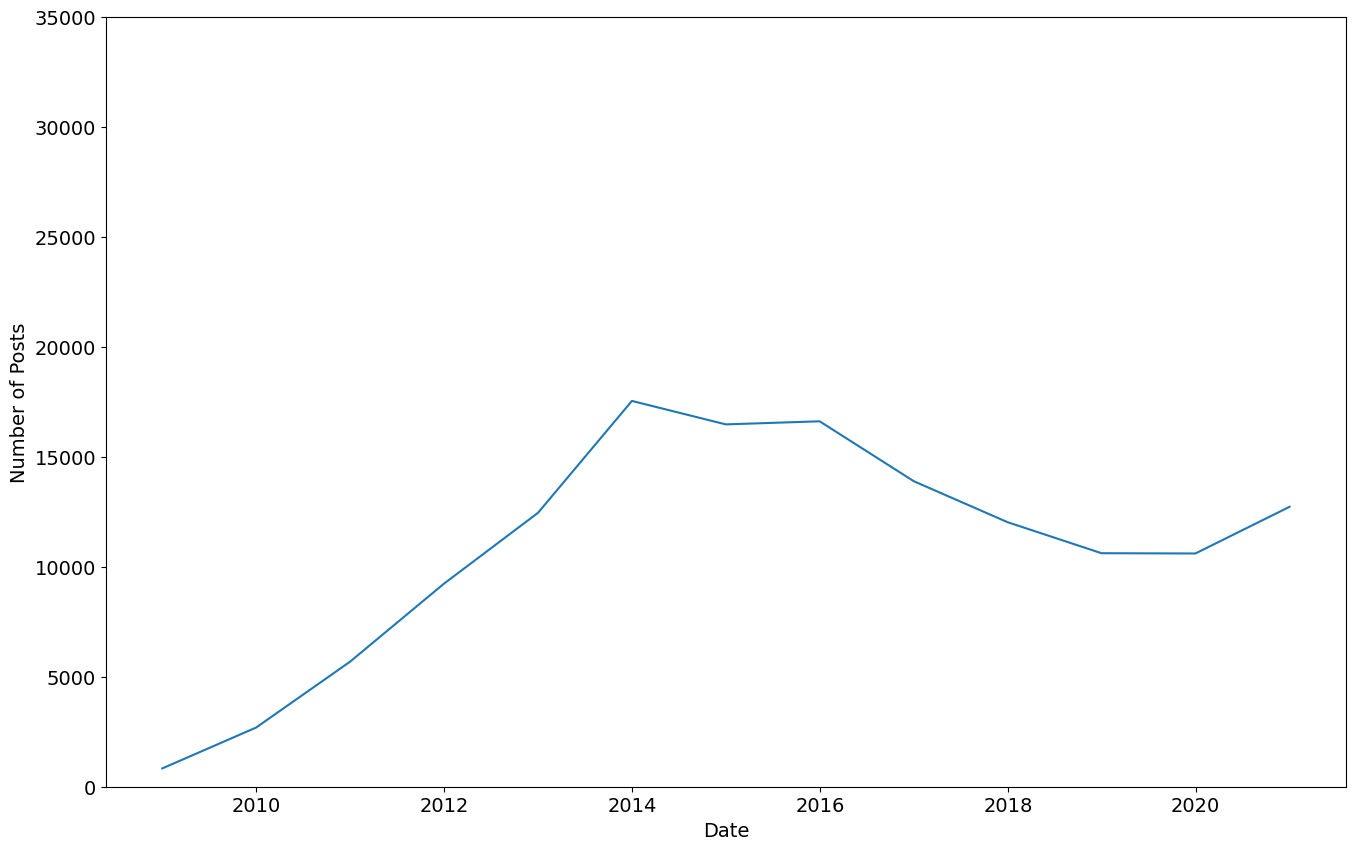

In [43]:
annual_df = reshaped_df.resample('YE').last()

plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylim(0, 35000)
plt.ylabel('Number of Posts', fontsize=14)
plt.plot(annual_df.index,annual_df['java'])

**Challenge**: Show two line (e.g. for Java and Python) on the same chart.

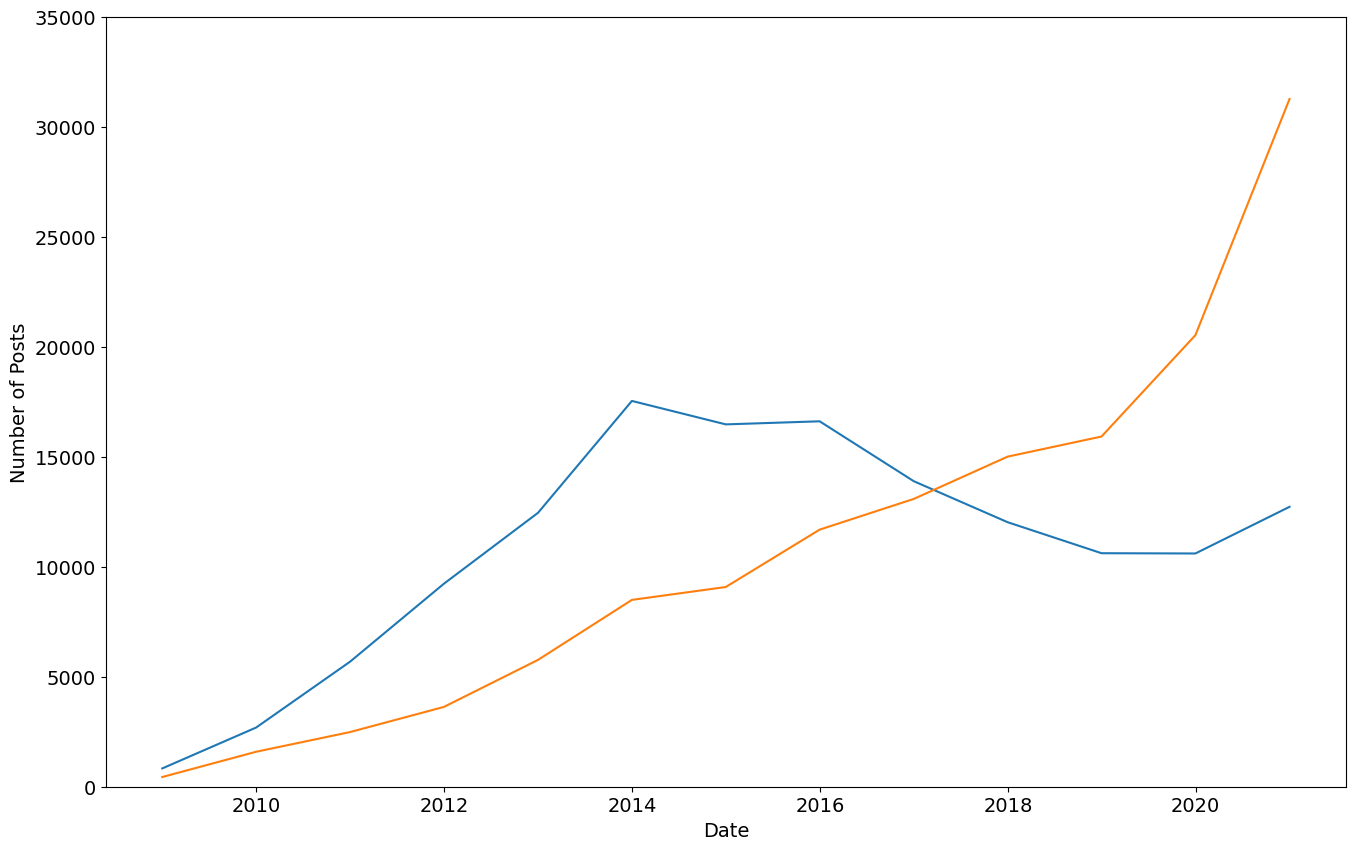

In [42]:
annual_df = reshaped_df.resample('YE').last()

plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylim(0, 35000)
plt.ylabel('Number of Posts', fontsize=14)
plt.plot(annual_df.index,annual_df['java'])
plt.plot(annual_df.index,annual_df['python'])

now lets combine all languages.

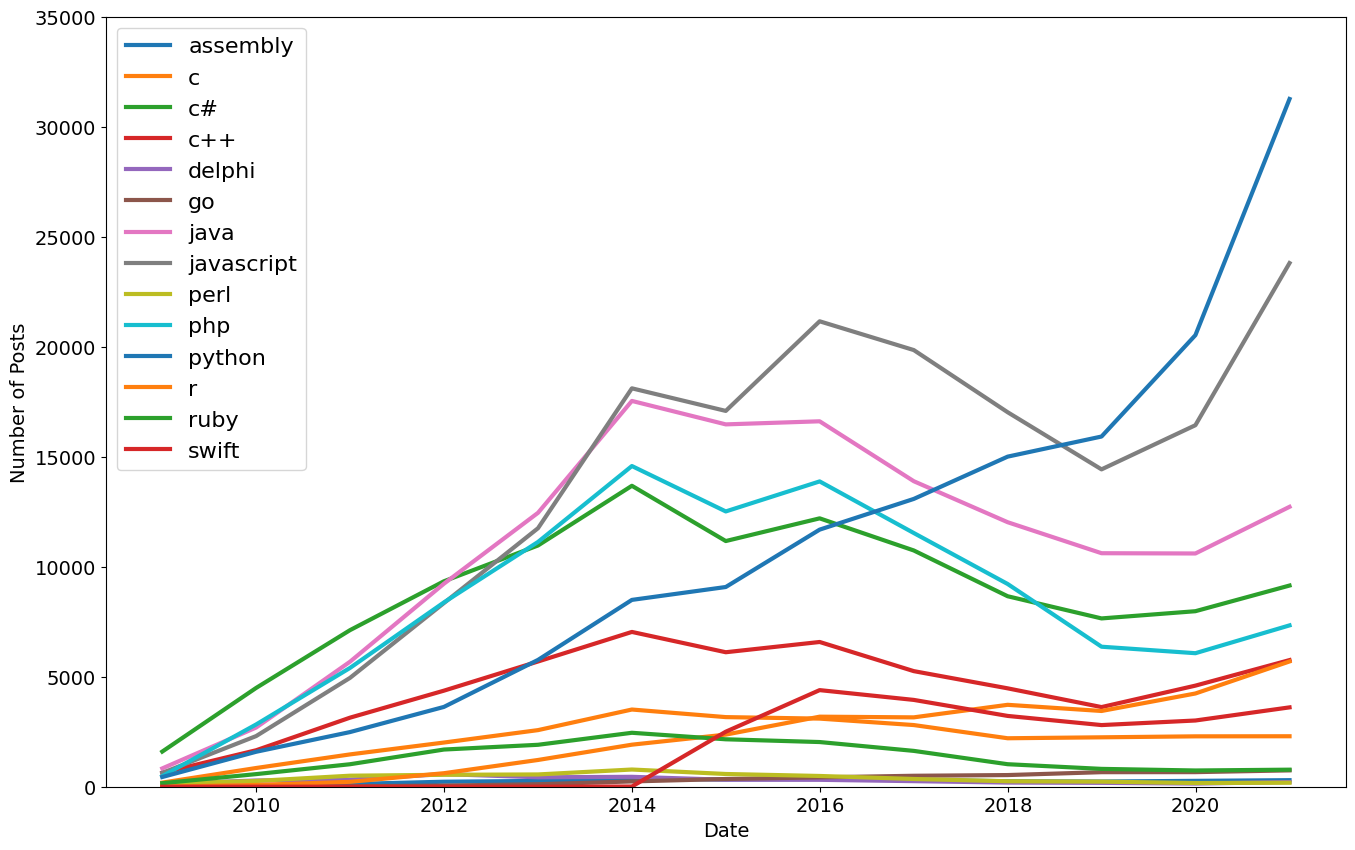

In [45]:
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylim(0, 35000)
plt.ylabel('Number of Posts', fontsize=14)
for column in annual_df.columns:
  plt.plot(annual_df.index,annual_df[column],linewidth=3,
           label=annual_df[column].name)

plt.legend(fontsize=16)


# Smoothing out Time Series Data

Time series data can be quite noisy, with a lot of up and down spikes. To better see a trend we can plot an average of, say 6 or 12 observations. This is called the rolling mean. We calculate the average in a window of time and move it forward by one overservation. Pandas has two handy methods already built in to work this out: [rolling()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html) and [mean()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.window.rolling.Rolling.mean.html).

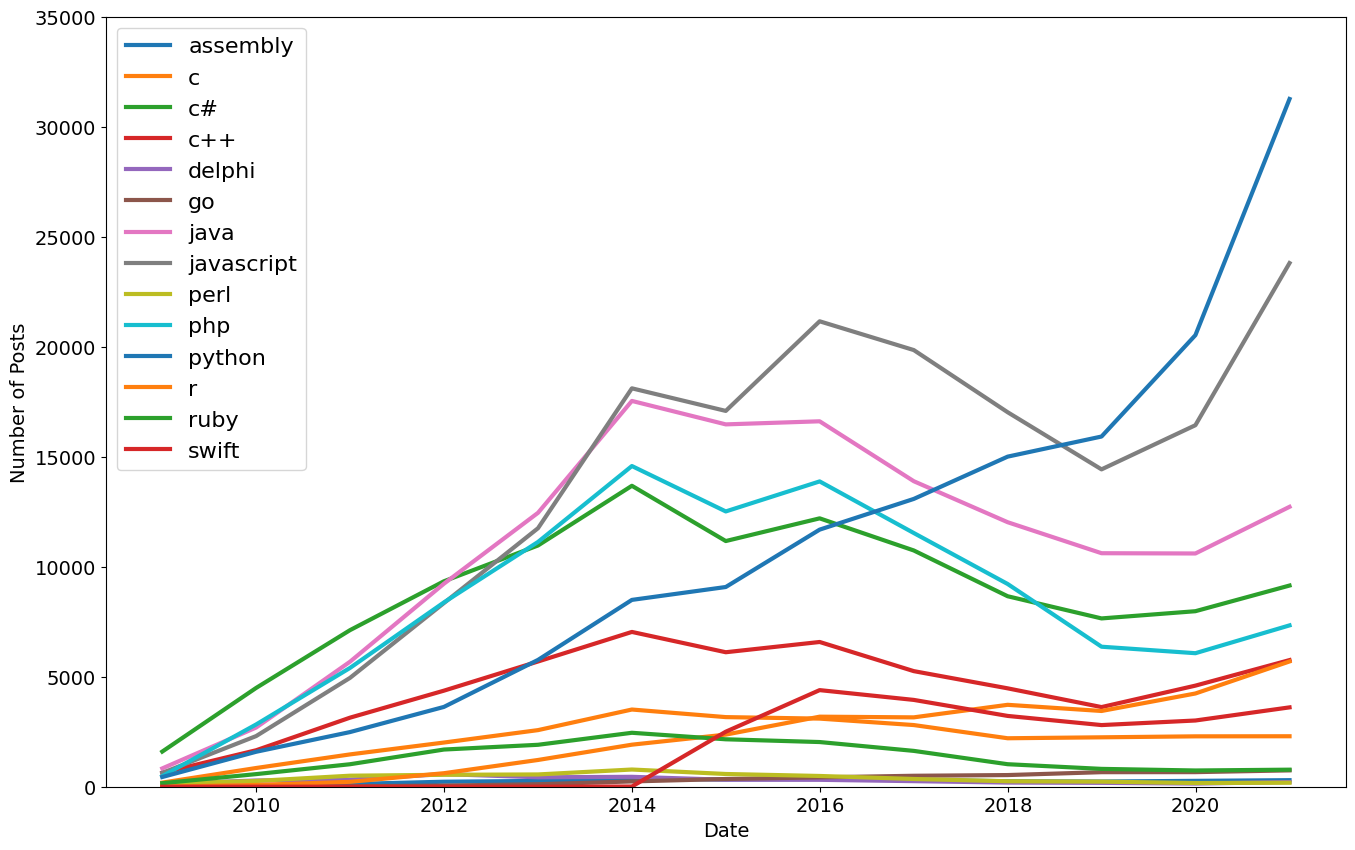

In [46]:
roll_df=annual_df.rolling(window=6).mean()
plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylim(0, 35000)
plt.ylabel('Number of Posts', fontsize=14)
for column in annual_df.columns:
  plt.plot(annual_df.index,annual_df[column],linewidth=3,
           label=annual_df[column].name)

plt.legend(fontsize=16)